# Part B

Create an auto-explainer for creating a DFA for the language $L_{b,n} = \{w \in {0, 1, ..., b-1}*$ : w represents a multiple of the integer n $\}$. 

Make an *explainer* of how students can generate that DFA, and why the DFA you created is correct.

### Approach

1. Create a DFA with $n$ states, given by $Q=\{q_0, q_1, q_2, ..., q_{n-1}\}$
2. Each state will contain $b$ transitions, given by an alphabet of $\sum=\{0, 1, ..., b-1\}$
3. The transition function $\delta$ will be given by the function $f_b(k,i)=bi+k$ for $k \in \sum$ and $i \in Q$ where $i$ is the index of the current state in $Q$ 

### Coding Approach
First, we import the necessary libraries. We use `automata` for DFA work and visualization, which is built on the `pygraphviz` library.

In [74]:
from automata.fa.dfa import DFA

Now, we'll write a class to perform each of the steps we're trying to show. 

In [93]:
class myDFA():
    def __init__(self, n_states, n_alphabet=2, transitions={}, initial_state="q0", accepting_states={}):
        self.states = {f"q{i}" for i in range(n_states)}
        self.alphabet = {str(i) for i in range(n_alphabet)}
        self.transitions={q:{a:q for a in self.alphabet} for q in self.states}
        self.initial_state='q0'
        self.accepting_states={'q0'}

    def generate_transitions(self, function):
        self.transitions = function(self.states, self.alphabet)

    def generate_dfa(self):
        """
        generates a DFA from the class' current attributes
        """
        my_dfa = DFA(
            states=self.states,
            input_symbols=self.alphabet,
            transitions=self.transitions,
            initial_state=self.initial_state,
            final_states=self.accepting_states
        )

        return my_dfa
    
    def show_dfa(self, name="dfa"):
        my_dfa = self.generate_dfa()
        my_dfa.show_diagram(path=f"{name}.png")

    def __str__(self):
        print(f"Q: {self.states}")
        print(f"A: {self.alphabet}")
        print(f"i: {self.initial_state}")
        print(f"F: {self.accepting_states}")
        print(f"transitions: ")
        for key, item in self.transitions.items():
            print(key, item)
        return ""



In [94]:
def transition_function(states, alphabet):
    transitions = {}

    n = len(states)
    b = len(alphabet)

    for i in range(n):
        transitions[f"q{i}"] = {}
        for j in range(b):
            transitions[f"q{i}"][f"{j}"] = f"q{(b*i + j) % n}"

    return transitions

In [95]:
my_dfa = myDFA(3)
print(my_dfa)
my_dfa.show_dfa()

Q: {'q2', 'q1', 'q0'}
A: {'1', '0'}
i: q0
F: {'q0'}
transitions: 
q2 {'1': 'q2', '0': 'q2'}
q1 {'1': 'q1', '0': 'q1'}
q0 {'1': 'q0', '0': 'q0'}



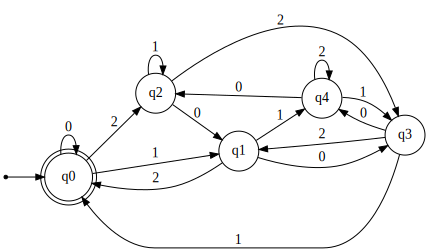

In [96]:
my_dfa = myDFA(5, 3)
my_dfa.generate_transitions(transition_function)
my_dfa.generate_dfa().show_diagram()